In [1]:


import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

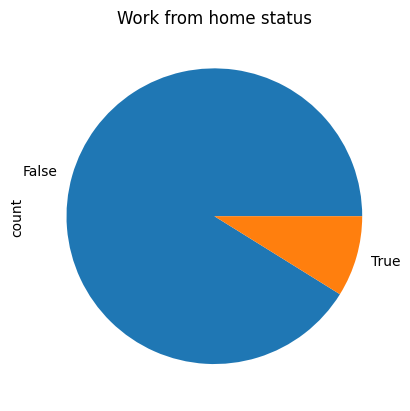

In [8]:
df['job_work_from_home'].value_counts().plot(kind='pie')
plt.title('Work from home status')
plt.show()

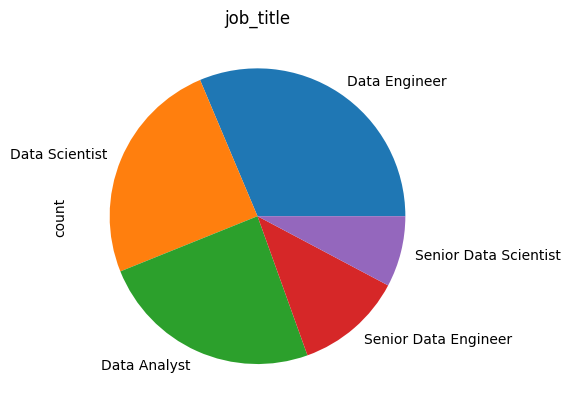

In [11]:
df['job_title'].value_counts().head(5).plot(kind='pie')
plt.title('job_title')
plt.show()

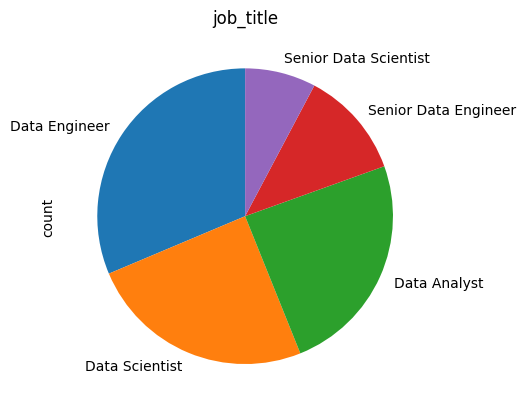

In [12]:
df['job_title'].value_counts().head(5).plot(kind='pie',startangle=90)
plt.title('job_title')
plt.show()

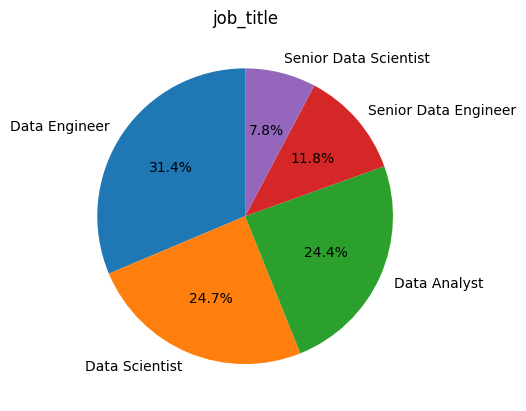

In [16]:
df['job_title'].value_counts().head(5).plot(kind='pie',startangle=90,autopct='%1.1f%%')
plt.title('job_title')
plt.ylabel('')
plt.show()


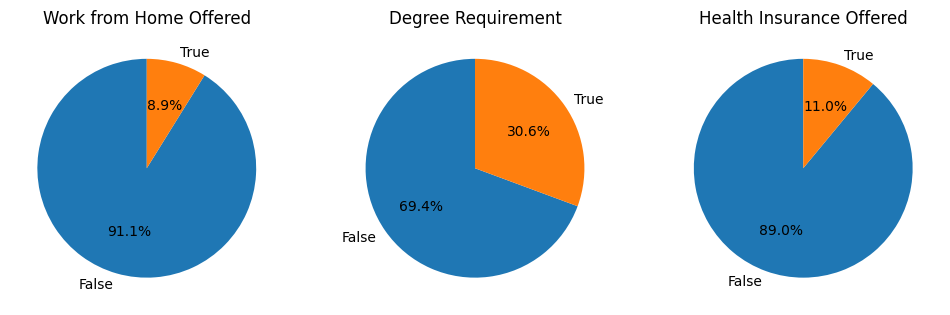

In [29]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

# plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.show()

<span style ="color:green;font-width:bold; font-size:32px;"> Practice Prompts </span>

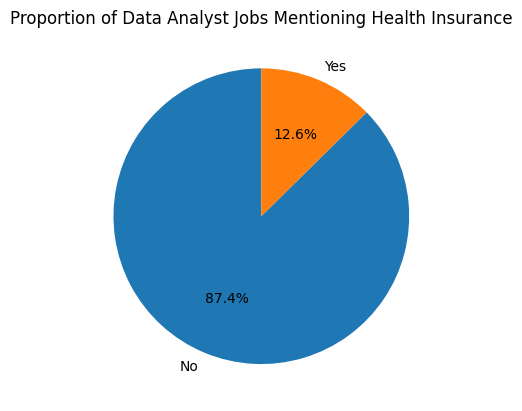

In [30]:
# Matplotlib Pie Plots
# Problem Statement:
# Create a pie chart to show the proportion of job postings that mention health insurance for Data Analyst roles only:

# Create a new DataFrame called df_DA that only gets Data Analyst roles.
# Then count the number of data analyst roles that mention or not mention health insurance by using the job_health_insurance column.
# Plot this using plt.pie(), setting labels parameter to ['No', 'Yes'], startangle to 90, and format values to display similarly to 23.1%.
# Set the title to 'Proportion of Data Analyst Jobs Mentioning Health Insurance'.

df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
health_insurance_counts = df_DA['job_health_insurance'].value_counts()
plt.pie(health_insurance_counts, labels=['No', 'Yes'], autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Data Analyst Jobs Mentioning Health Insurance')
plt.show()


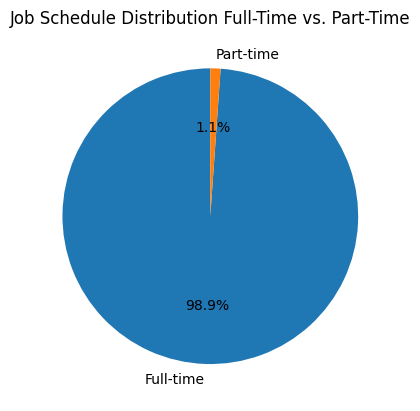

In [31]:
# Matplotlib Pie Plots
# Problem Statement:
# Create a pie chart showing the count of job postings per job schedule types (for only jobs that are either 'Full-time' and 'Part-time') in the DataFrame.
# Create a DataFrame to filter out these job_schedule_type called df_ft_pt.
# Plot this using plt.pie(), setting labels parameter to the index, startangle to 90, and format values to display similarly to 23.1%.
# Add a title 'Job Schedule Full-time vs. Part-time'.
df_ft_pt = df[(df['job_schedule_type'] == 'Full-time') | (df['job_schedule_type'] == 'Part-time')].copy()
job_schedule_counts = df_ft_pt['job_schedule_type'].value_counts()
plt.pie(job_schedule_counts, labels=job_schedule_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Job Schedule Distribution Full-Time vs. Part-Time')
plt.show()




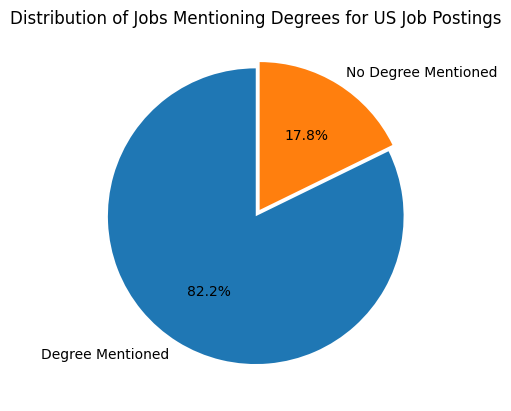

In [34]:
# Matplotlib Pie Plots
# Problem Statement:
# Create a pie chart to show the distribution of job postings that mention a degree in the job posting versus those that do not.
# Only get job postings located in the US, create a new DataFrame with this filtered data called df_US.
# Use the job_no_degree_mention column for this purpose.
# Customize the pie chart by exploding the slice for jobs that do not mention a degree.
# (Use the explode parameter set to (0, 0.1) inside of plt.pie())
# Set the chart title as 'Distribution of Jobs Mentioning Degrees for US Job Postings'.


df_US = df[df['job_country'] == 'United States'].copy()
degree_counts = df_US['job_no_degree_mention'].value_counts()
plt.pie(degree_counts, labels=['Degree Mentioned', 'No Degree Mentioned'], autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()
